# Lab Practice Ensemble learning 1.1:  BOOTSTRAP (classwork)  | Machine Learning II
#### ESU  Jan-2025
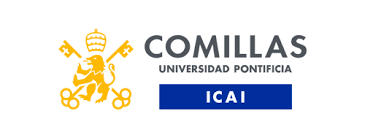

LEARNING OBJECTIVES
- How to apply the bootstrap approach in a more complex case (simple linear regression)
- Understand the variability of the parameters of a simple linear regression model due to sampling

---
## Import modules

In [1]:
import numpy as np  # linear algebra
import pandas as pd  # data management (dataframes)
import matplotlib.pyplot as plt  # plotting
import seaborn as sns  # plotting
from scipy import stats # basic statistics

from sklearn.linear_model import LinearRegression
from sklearn.utils import resample  # allows implementing bootstrap

---
### 3. A more complex case: Simple linear regression estimation

see https://en.wikipedia.org/wiki/Simple_linear_regression#Unbiasedness

#### 3.1 Create the simulated data

In [2]:
# set the ramdom seed for reproductivility
np.random.seed(99999)

In [3]:
# TRUE (UNKNOWN) REGRESSION LINE
# y = beta_0 + beta_1 * x + E
# where E is a r.v.  ~ Normal(mu = 0, std = 3)

# the straight line (deterministic part)
sample_size = 1000
beta_0_true = 2
beta_1_true = 5
x = np.linspace(0,1,num=sample_size)
y_det_true = beta_0_true + beta_1_true * x

# create the random variable for the noise
std_err_true = 3
E = stats.norm(loc = 0, scale = std_err_true)

# sample
# random sample from the random variable
y = y_det_true + E.rvs(size = sample_size)# es un array de 1000 elementos

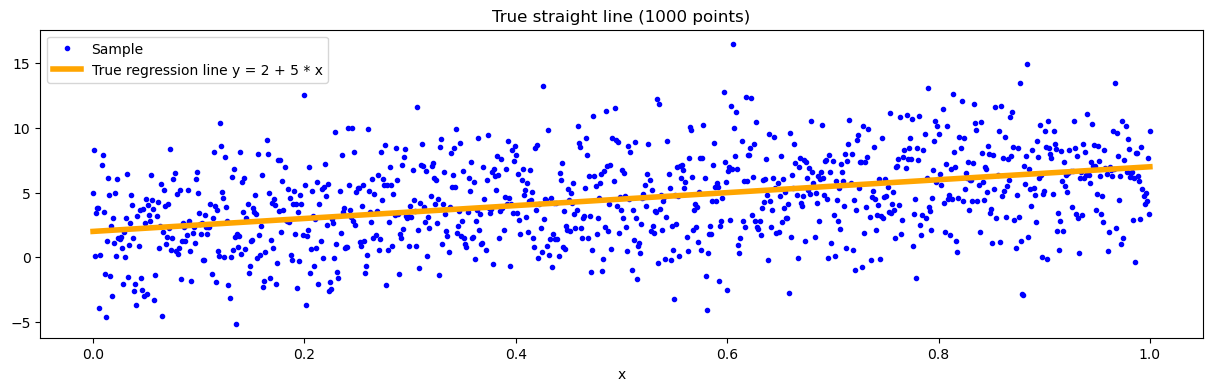

In [26]:
# plot the true line and the points for visual checking
# y_det_true es la recta real, la determinista. 
# y es la recta con ruido

fig = plt.figure(1, figsize=(15, 4))
plt.plot(x,y,'.',color='blue', label='Sample')
plt.plot(x,y_det_true,'-',color='orange', linewidth = 4, label=f'True regression line y = {beta_0_true} + {beta_1_true} * x')
plt.xlabel('x')
plt.legend()
plt.title(f'True straight line ({len(y)} points)')
plt.show()

#### 2.3 Fit regression line using the sample

In [4]:
# Prepare the dataframe for easy 
data = {'x': x, 'y': y}
df = pd.DataFrame(data)
df

,x,y
0,0.000000,3.872282
1,0.001001,5.829894
2,0.002002,-2.968801
3,0.003003,3.538865
4,0.004004,1.357278
...,...,...
995,0.995996,4.356458
996,0.996997,8.566238
997,0.997998,7.133485
998,0.998999,7.481013


Text(0.5, 1.0, 'y = 2.1350138762621227 + 4.929748737789255 * x   (R-squared = 0.19099715366511605)')

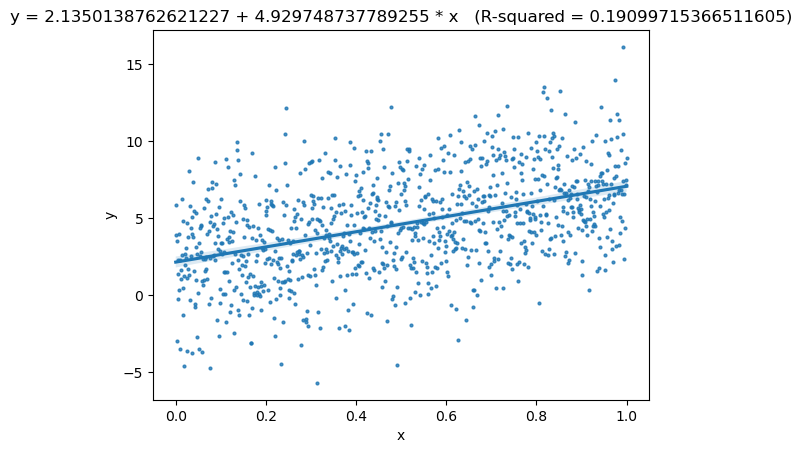

In [5]:
# fit regression line using of the available data
lin_reg_sample = LinearRegression()
lin_reg_sample.fit(df[['x']], df[['y']]) 

beta_0_sample=lin_reg_sample.intercept_[0]
beta_1_sample=lin_reg_sample.coef_.ravel()[0]
r_squared_sample=lin_reg_sample.score(df[['x']], df[['y']])

# plot the resulting regression line and a 95% confidence interval for that regression:
sns.regplot(x="x", y="y", data=df, scatter_kws={"s": 4});
plt.title(f'y = {beta_0_sample} + {beta_1_sample} * x   (R-squared = {r_squared_sample})')

##### 2.4 Apply the bootstrap approach

In [6]:
# Create the function that estimate beta_0, beta_1 and r_squared from a particular df_bag sample
def boot_function_regress_line (df_bag):
    
    boot_stats = pd.DataFrame()

    lin_reg_sample = LinearRegression()
    lin_reg_sample.fit(df_bag[['x']], df_bag[['y']]) 

    beta_0_boot=lin_reg_sample.intercept_[0]
    beta_1_boot=lin_reg_sample.coef_.ravel()[0]
    r_squared_boot=lin_reg_sample.score(df_bag[['x']], df_bag[['y']])

    d = dict(beta_0=beta_0_boot, 
             beta_1=beta_1_boot,
             r_squared=r_squared_boot )
    
    boot_stats = pd.DataFrame([d])

    return boot_stats


In [8]:
# check the function (Tiene que dar el mismo resultado que el anterior)
st = boot_function_regress_line (df)
st

,beta_0,beta_1,r_squared
0,2.135014,4.929749,0.190997


In [9]:
# Vamos a obtener los valores de beta_0, beta_1 y r_squared para cada una de las 5000 muestras bootstrap.

# run bootstrap

# set the ramdom seed for reproductivility
np.random.seed(99999)

# Defining number of bootstrap (re)samples
n_boots = 5000

# Initializing DataFrame, to hold bootstrapped statistics
bootstrapped_stats = pd.DataFrame()

# In each iteration a bootstrap sample is formed
for i in range(n_boots):

    # sampling the original data in two sets: tr (train) and ts (test)
    train_set = resample(df,                # original dataframe for resampling
                         replace=True,      # sampling n_samples from data, with replacement
                         n_samples=len(df)) # the train_set sample has the same size than the original df
    
    # the test set consists of all observations not in train (usefull for computing OOB stats)
    test_set = df[~df.index.isin(train_set.index)]
    
    # compute bootstrapped stats using the training set
    boot_function_regress_line_i = boot_function_regress_line(train_set)
    bootstrapped_stats = pd.concat(objs=[bootstrapped_stats, boot_function_regress_line_i])



Main descriptive statistics:
            beta_0       beta_1    r_squared
count  5000.000000  5000.000000  5000.000000
mean      2.136145     4.925306     0.191146
std       0.184187     0.310031     0.020437
min       1.501234     3.736483     0.111084
10%       1.897477     4.527741     0.165505
25%       2.012425     4.716759     0.176951
50%       2.133440     4.927931     0.190879
75%       2.259697     5.133612     0.204859
90%       2.373169     5.322687     0.217461
max       3.000846     5.983284     0.263881

Correlation matrix:
           beta_0  beta_1  r_squared
beta_0     1.0000 -0.8639    -0.8042
beta_1    -0.8639  1.0000     0.9230
r_squared -0.8042  0.9230     1.0000

Empirical distribution of the stats:


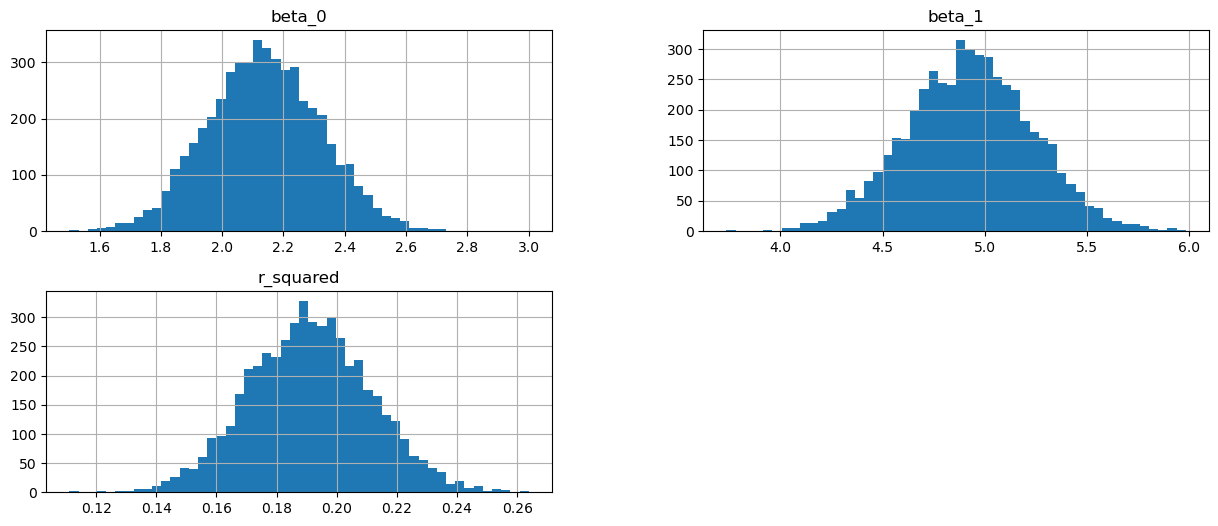

In [10]:
# Overview of the stats

# Overview of the stats
print('Main descriptive statistics:')
print(bootstrapped_stats.describe(percentiles=[0.1,0.25,0.75,0.9]))

# correlation matrix
mat_corr = bootstrapped_stats.corr()
print('\nCorrelation matrix:')
print(np.round(mat_corr, 4))

# histograms
print('\nEmpirical distribution of the stats:')
bootstrapped_stats.hist(figsize=(15, 6), bins = 50, sharex = False)
plt.draw()


In [11]:
bootstrapped_stats.columns

Index(['beta_0', 'beta_1', 'r_squared'], dtype='object')

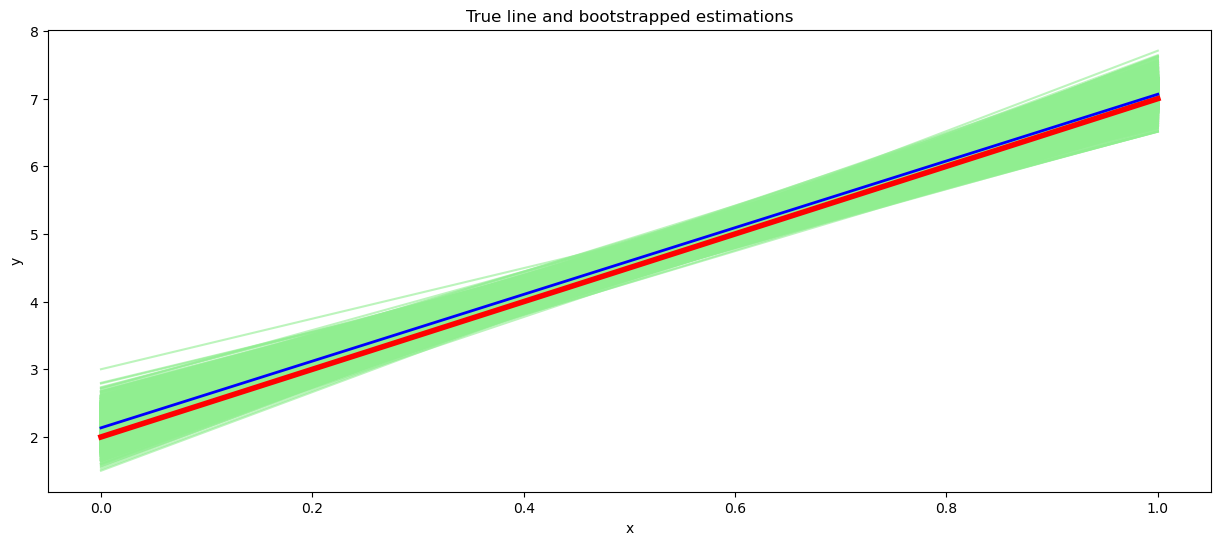

In [13]:
# Compare true line with estimated ones

# plot the true line and the points for visual checking
# Crear la gráfica
fig = plt.figure(1, figsize=(15, 6))
#plt.plot(x, y, '.', color='blue', label='Sample')  # Puntos de datos

# Dibujar las líneas estimadas
for _, row in bootstrapped_stats.iterrows():
    beta_0 = row['beta_0']
    beta_1 = row['beta_1']
    y_estimated = beta_0 + beta_1 * x
    plt.plot(x, y_estimated, '-', color='lightgreen', alpha=0.6, label=f'Estimation y = {beta_0:.2f} + {beta_1:.2f} * x')

plt.plot(x, y_det_true, '-', color='red', linewidth=4, label=f'True regression line y = {beta_0_true} + {beta_1_true} * x')# Línea verdadera
y = beta_0_sample + beta_1_sample*x
plt.plot(x, y, '-', color='blue', linewidth=2, label=f'True regression line y = {beta_0_sample} + {beta_1_sample} * x')  # Línea verdadera

# Configurar la gráfica
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'True line and bootstrapped estimations')
plt.show()

In [19]:
train_set

,x,y
37,0.373737,5.674977
76,0.767677,5.863040
85,0.858586,6.480455
61,0.616162,5.115700
11,0.111111,1.551017
...,...,...
17,0.171717,-0.523399
97,0.979798,4.789165
93,0.939394,8.072137
88,0.888889,7.372903


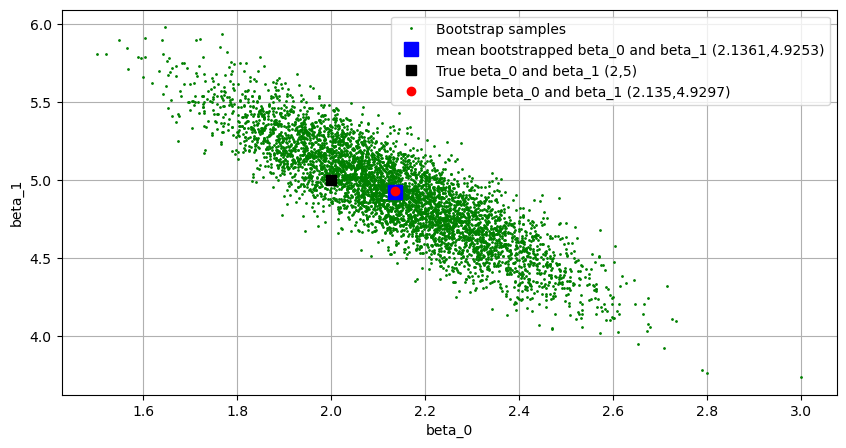

In [16]:
# Compare variance of the mean estimator according to bootstrap and theory
mean_boots_means = np.mean(bootstrapped_stats.beta_0)
mean_boots_vars =  np.mean(bootstrapped_stats.beta_1)

# Show all the statistics together
fig = plt.figure(1, figsize=(10, 5))
plt.plot(bootstrapped_stats.beta_0, bootstrapped_stats.beta_1, '.', color='g', markersize = 2, label = 'Bootstrap samples')
plt.plot(mean_boots_means, mean_boots_vars, 's', color='b', markersize = 10, label = f'mean bootstrapped beta_0 and beta_1 ({np.round(mean_boots_means,4)},{np.round(mean_boots_vars,4)})')
plt.plot(beta_0_true, beta_1_true, 's', color='k', markersize = 7, label = f'True beta_0 and beta_1 ({beta_0_true},{beta_1_true})')
plt.plot(beta_0_sample, beta_1_sample, 'o', color='r', markersize = 6, label = f'Sample beta_0 and beta_1 ({np.round(beta_0_sample,4)},{np.round(beta_1_sample,4)})')
plt.xlabel('beta_0')
plt.ylabel('beta_1')
plt.legend()
plt.grid()
plt.show()